# Cell 1：导入库、读取数据

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

factor_file = PROCESSED_DIR / "etf_factors_long.csv"

factor_data = pd.read_csv(factor_file, encoding="utf-8-sig")
factor_data["date"] = pd.to_datetime(factor_data["date"])
factor_data = factor_data.sort_values(["date", "symbol"]).reset_index(drop=True)

required_cols = [
    "date", "symbol", "name", "daily_return",
    "alpha_score", "alpha_rank"
]

missing_cols = [col for col in required_cols if col not in factor_data.columns]
if missing_cols:
    raise ValueError(f"缺失必要字段: {missing_cols}")

print("数据形状:", factor_data.shape)
print("ETF 数量:", factor_data["symbol"].nunique())
print("日期范围:", factor_data["date"].min(), "到", factor_data["date"].max())

factor_data[required_cols].dropna().head()

数据形状: (25810, 32)
ETF 数量: 14
日期范围: 2018-01-02 00:00:00 到 2026-06-12 00:00:00


,date,symbol,name,daily_return,alpha_score,alpha_rank
540,2018-04-03,159915,创业板ETF,-0.013423,1.263204,1.0
541,2018-04-03,510300,沪深300ETF,-0.007643,-0.897683,9.0
542,2018-04-03,510500,中证500ETF,-0.008381,-0.282561,5.0
543,2018-04-03,512100,中证1000ETF,-0.011798,-0.045162,4.0
544,2018-04-03,512660,军工ETF,-0.011521,1.064884,2.0



# Cell 2 ：定义回测函数

In [2]:
def get_rebalance_dates(all_dates, freq: str):
    """
    根据调仓频率生成调仓日期。
    
    daily: 每个交易日调仓
    weekly: 每周最后一个交易日调仓
    monthly: 每月最后一个交易日调仓
    """
    all_dates = pd.to_datetime(pd.Series(sorted(all_dates)))

    if freq == "daily":
        return list(all_dates)

    if freq == "weekly":
        return list(all_dates.groupby(all_dates.dt.to_period("W-FRI")).max())

    if freq == "monthly":
        return list(all_dates.groupby(all_dates.dt.to_period("M")).max())

    raise ValueError("freq must be one of: daily, weekly, monthly")


def build_target_weights(df, top_n: int = 1, rebalance_freq: str = "daily"):
    """
    基于 alpha_score 构造目标权重。
    
    注意：
    - 在调仓日 t 收盘后观察 alpha_score；
    - 生成 t 日信号；
    - 实际权重从 t+1 日开始生效；
    - Top N 等权持有。
    """
    df = df.copy()
    df = df.sort_values(["date", "symbol"])

    all_dates = sorted(df["date"].unique())
    symbols = sorted(df["symbol"].unique())

    alpha_wide = df.pivot(index="date", columns="symbol", values="alpha_score").reindex(all_dates)
    rebalance_dates = get_rebalance_dates(all_dates, rebalance_freq)

    signal_weights = pd.DataFrame(0.0, index=rebalance_dates, columns=symbols)

    for date in rebalance_dates:
        if date not in alpha_wide.index:
            continue

        scores = alpha_wide.loc[date].dropna()

        if len(scores) == 0:
            continue

        selected = scores.sort_values(ascending=False).head(top_n).index
        signal_weights.loc[date, selected] = 1.0 / len(selected)

    # 将调仓日权重扩展到每日，并滞后一日，避免未来函数
    daily_weights = (
        signal_weights
        .reindex(all_dates)
        .ffill()
        .fillna(0.0)
        .shift(1)
        .fillna(0.0)
    )

    daily_weights.index.name = "date"

    return daily_weights


def calculate_performance(returns: pd.Series, turnover: pd.Series = None):
    """
    计算策略绩效指标。
    """
    returns = returns.dropna().copy()

    if len(returns) == 0:
        return {}

    nav = (1 + returns).cumprod()

    total_return = nav.iloc[-1] - 1
    annualized_return = nav.iloc[-1] ** (252 / len(returns)) - 1
    annualized_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        annualized_return / annualized_volatility
        if annualized_volatility != 0
        else np.nan
    )

    drawdown = nav / nav.cummax() - 1
    max_drawdown = drawdown.min()

    calmar = (
        annualized_return / abs(max_drawdown)
        if max_drawdown < 0
        else np.nan
    )

    win_rate = (returns > 0).mean()

    result = {
        "total_return": total_return,
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "calmar": calmar,
        "win_rate": win_rate,
        "n_days": len(returns),
        "final_nav": nav.iloc[-1],
    }

    if turnover is not None:
        turnover = turnover.reindex(returns.index).fillna(0)
        result["avg_daily_turnover"] = turnover.mean()
        result["annualized_turnover"] = turnover.mean() * 252
        result["total_turnover"] = turnover.sum()

    return result


def backtest_alpha_strategy(
    df,
    top_n: int = 1,
    rebalance_freq: str = "daily",
    cost_rate: float = 0.001
):
    """
    回测 Alpha 策略。
    
    Parameters
    ----------
    top_n:
        持有 Alpha 得分最高的前 N 只 ETF。
    rebalance_freq:
        daily / weekly / monthly
    cost_rate:
        单边交易成本。例如 0.001 表示 0.1%。
    """
    df = df.copy()
    df = df.sort_values(["date", "symbol"])

    returns_wide = (
        df
        .pivot(index="date", columns="symbol", values="daily_return")
        .sort_index()
        .fillna(0.0)
    )

    weights = build_target_weights(
        df=df,
        top_n=top_n,
        rebalance_freq=rebalance_freq
    ).reindex(returns_wide.index).fillna(0.0)

    # 扣费前收益
    strategy_return_before_cost = (weights * returns_wide).sum(axis=1)

    # 换手率：从上一期权重切换到本期权重
    turnover = weights.diff().abs().sum(axis=1)
    turnover.iloc[0] = weights.iloc[0].abs().sum()

    transaction_cost = turnover * cost_rate

    # 扣费后收益
    strategy_return_after_cost = strategy_return_before_cost - transaction_cost

    # 从第一次真正持仓开始截取样本
    active = weights.abs().sum(axis=1) > 0

    if active.any():
        start_date = active[active].index[0]
        strategy_return_before_cost = strategy_return_before_cost.loc[start_date:]
        strategy_return_after_cost = strategy_return_after_cost.loc[start_date:]
        turnover = turnover.loc[start_date:]
        transaction_cost = transaction_cost.loc[start_date:]
        weights = weights.loc[start_date:]
        returns_wide = returns_wide.loc[start_date:]

    nav_before_cost = (1 + strategy_return_before_cost).cumprod()
    nav_after_cost = (1 + strategy_return_after_cost).cumprod()

    # ETF 池等权基准
    benchmark_return = returns_wide.mean(axis=1)
    benchmark_nav = (1 + benchmark_return).cumprod()

    perf_before = calculate_performance(strategy_return_before_cost, turnover)
    perf_after = calculate_performance(strategy_return_after_cost, turnover)
    perf_benchmark = calculate_performance(benchmark_return)

    result = {
        "top_n": top_n,
        "rebalance_freq": rebalance_freq,
        "cost_rate": cost_rate,
        "weights": weights,
        "turnover": turnover,
        "transaction_cost": transaction_cost,
        "strategy_return_before_cost": strategy_return_before_cost,
        "strategy_return_after_cost": strategy_return_after_cost,
        "benchmark_return": benchmark_return,
        "nav_before_cost": nav_before_cost,
        "nav_after_cost": nav_after_cost,
        "benchmark_nav": benchmark_nav,
        "perf_before": perf_before,
        "perf_after": perf_after,
        "perf_benchmark": perf_benchmark,
    }

    return result

# Cell 3：跑参数组合

In [3]:
top_n_list = [1, 2, 3]
rebalance_freq_list = ["daily", "weekly", "monthly"]
cost_rate_list = [0.0, 0.0005, 0.001, 0.002]

backtest_results = {}
summary_rows = []

for top_n in top_n_list:
    for freq in rebalance_freq_list:
        for cost_rate in cost_rate_list:
            key = f"top{top_n}_{freq}_cost{cost_rate}"

            result = backtest_alpha_strategy(
                df=factor_data,
                top_n=top_n,
                rebalance_freq=freq,
                cost_rate=cost_rate
            )

            backtest_results[key] = result

            row = {
                "strategy": key,
                "top_n": top_n,
                "rebalance_freq": freq,
                "cost_rate": cost_rate,

                "total_return_before_cost": result["perf_before"]["total_return"],
                "annualized_return_before_cost": result["perf_before"]["annualized_return"],
                "sharpe_before_cost": result["perf_before"]["sharpe"],
                "max_drawdown_before_cost": result["perf_before"]["max_drawdown"],

                "total_return_after_cost": result["perf_after"]["total_return"],
                "annualized_return_after_cost": result["perf_after"]["annualized_return"],
                "annualized_volatility_after_cost": result["perf_after"]["annualized_volatility"],
                "sharpe_after_cost": result["perf_after"]["sharpe"],
                "max_drawdown_after_cost": result["perf_after"]["max_drawdown"],
                "calmar_after_cost": result["perf_after"]["calmar"],
                "win_rate_after_cost": result["perf_after"]["win_rate"],

                "avg_daily_turnover": result["perf_after"]["avg_daily_turnover"],
                "annualized_turnover": result["perf_after"]["annualized_turnover"],
                "total_turnover": result["perf_after"]["total_turnover"],

                "benchmark_total_return": result["perf_benchmark"]["total_return"],
                "benchmark_annualized_return": result["perf_benchmark"]["annualized_return"],
                "benchmark_sharpe": result["perf_benchmark"]["sharpe"],
                "benchmark_max_drawdown": result["perf_benchmark"]["max_drawdown"],
            }

            summary_rows.append(row)

backtest_summary = pd.DataFrame(summary_rows)

backtest_summary = backtest_summary.sort_values(
    by="sharpe_after_cost",
    ascending=False
).reset_index(drop=True)

summary_file = PROCESSED_DIR / "backtest_summary.csv"
backtest_summary.to_csv(summary_file, index=False, encoding="utf-8-sig")

print(f"已保存回测汇总结果: {summary_file}")
backtest_summary.head(20)

已保存回测汇总结果: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\backtest_summary.csv


,strategy,top_n,rebalance_freq,cost_rate,total_return_before_cost,annualized_return_before_cost,sharpe_before_cost,max_drawdown_before_cost,total_return_after_cost,annualized_return_after_cost,...,max_drawdown_after_cost,calmar_after_cost,win_rate_after_cost,avg_daily_turnover,annualized_turnover,total_turnover,benchmark_total_return,benchmark_annualized_return,benchmark_sharpe,benchmark_max_drawdown
0,top2_weekly_cost0.0,2,weekly,0.0000,4.289934,0.235502,0.882007,-0.377715,4.289934,0.235502,...,-0.377715,0.623493,0.516877,0.157683,39.736020,313.000000,1.098560,0.098673,0.539174,-0.367244
1,top3_weekly_cost0.0,3,weekly,0.0000,3.214204,0.200353,0.835789,-0.360241,3.214204,0.200353,...,-0.360241,0.556163,0.526448,0.138875,34.996474,275.666667,1.098560,0.098673,0.539174,-0.367244
2,top3_daily_cost0.0,3,daily,0.0000,3.063335,0.194703,0.821339,-0.304222,3.063335,0.194703,...,-0.304222,0.640004,0.520141,0.376469,94.870091,747.666667,1.091987,0.098184,0.536622,-0.367244
3,top2_weekly_cost0.0005,2,weekly,0.0005,4.289934,0.235502,0.882007,-0.377715,3.524330,0.211223,...,-0.396774,0.532350,0.512846,0.157683,39.736020,313.000000,1.098560,0.098673,0.539174,-0.367244
4,top1_weekly_cost0.0,1,weekly,0.0000,4.779489,0.249463,0.781378,-0.428921,4.779489,0.249463,...,-0.428921,0.581606,0.519395,0.192947,48.622670,383.000000,1.098560,0.098673,0.539174,-0.367244
5,top3_weekly_cost0.0005,3,weekly,0.0005,3.214204,0.200353,0.835789,-0.360241,2.672922,0.179586,...,-0.378998,0.473843,0.525441,0.138875,34.996474,275.666667,1.098560,0.098673,0.539174,-0.367244
6,top1_monthly_cost0.0,1,monthly,0.0000,4.145504,0.233119,0.745656,-0.431163,4.145504,0.233119,...,-0.431163,0.540675,0.512690,0.075635,19.059898,149.000000,1.105455,0.099922,0.544482,-0.367244
7,top3_monthly_cost0.0,3,monthly,0.0000,2.433900,0.170947,0.736000,-0.388529,2.433900,0.170947,...,-0.388529,0.439985,0.518274,0.054992,13.857868,108.333333,1.105455,0.099922,0.544482,-0.367244
8,top1_monthly_cost0.0005,1,monthly,0.0005,4.145504,0.233119,0.745656,-0.431163,3.778138,0.221490,...,-0.437401,0.506378,0.512183,0.075635,19.059898,149.000000,1.105455,0.099922,0.544482,-0.367244
9,top2_daily_cost0.0,2,daily,0.0000,2.943147,0.190160,0.707141,-0.350795,2.943147,0.190160,...,-0.350795,0.542084,0.520645,0.443605,111.788520,881.000000,1.091987,0.098184,0.536622,-0.367244


# Cell 4：选择基准策略并画图

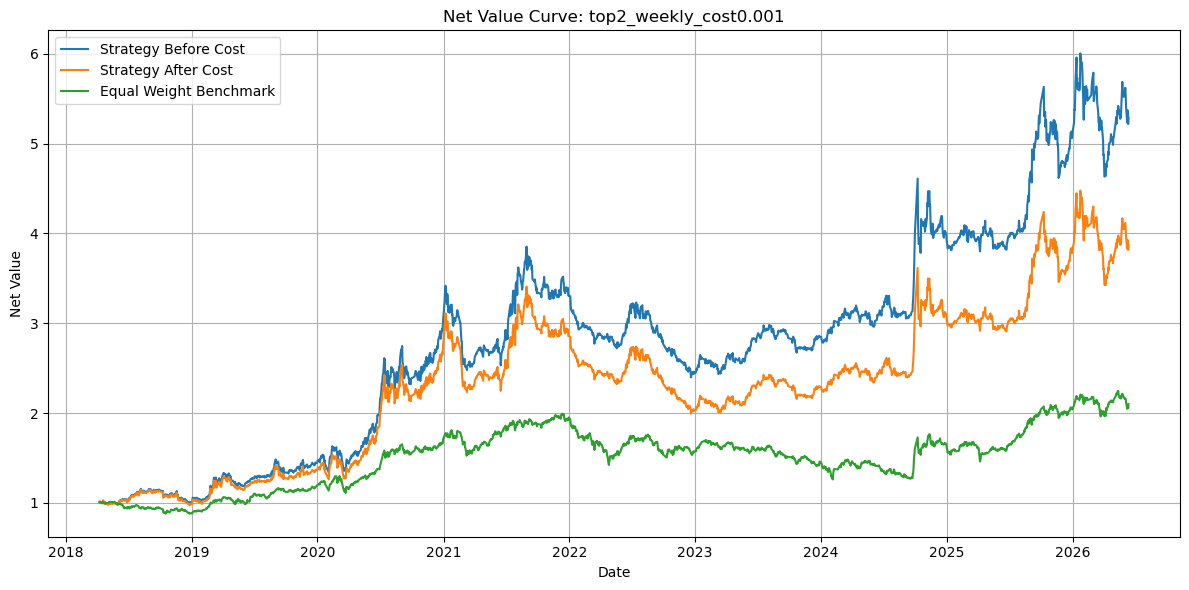

已保存净值图: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\net_value_curve_top2_weekly_cost0.001.png


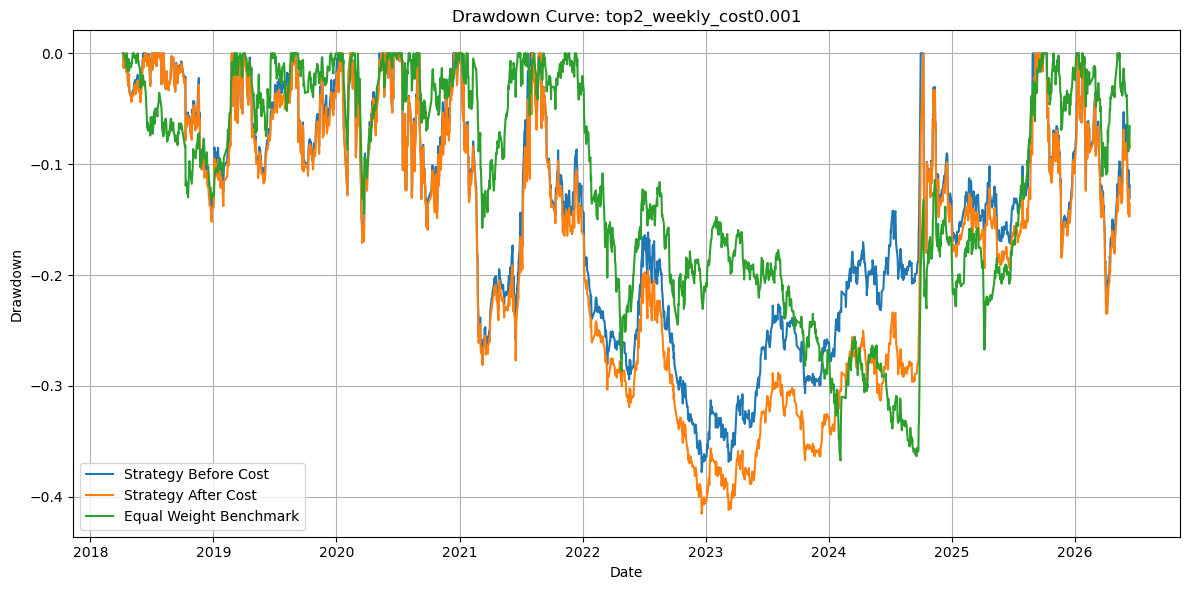

已保存回撤图: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\drawdown_curve_top2_weekly_cost0.001.png


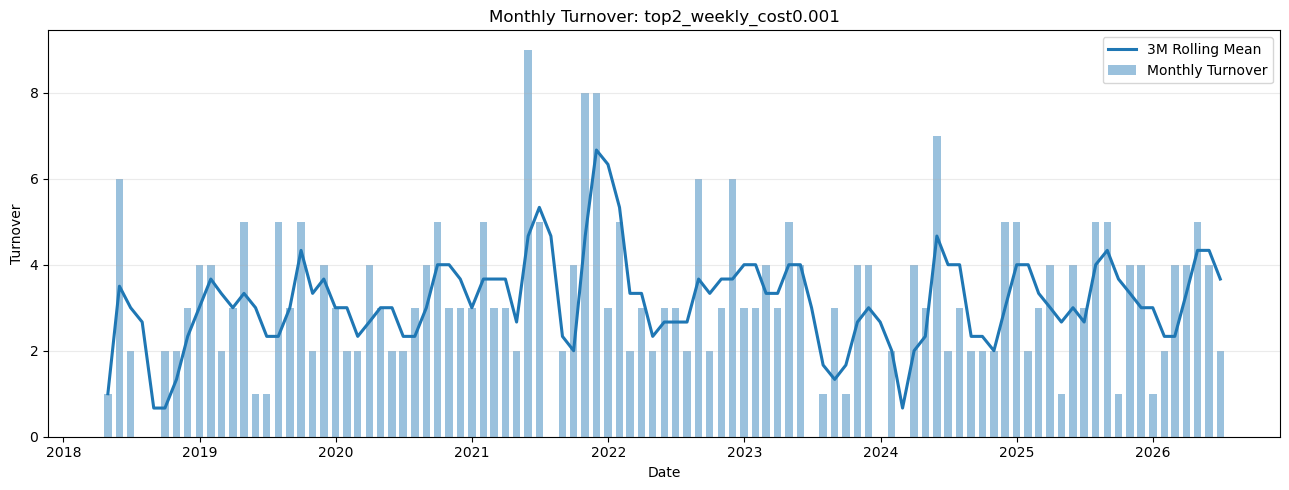

In [6]:
selected_key = "top2_weekly_cost0.001"

selected_result = backtest_results[selected_key]

nav_plot = pd.DataFrame({
    "Strategy Before Cost": selected_result["nav_before_cost"],
    "Strategy After Cost": selected_result["nav_after_cost"],
    "Equal Weight Benchmark": selected_result["benchmark_nav"],
})

plt.figure(figsize=(12, 6))
for col in nav_plot.columns:
    plt.plot(nav_plot.index, nav_plot[col], label=col)

plt.title(f"Net Value Curve: {selected_key}")
plt.xlabel("Date")
plt.ylabel("Net Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

nav_fig_file = FIGURE_DIR / f"net_value_curve_{selected_key}.png"
plt.savefig(nav_fig_file, dpi=300)
plt.show()

print(f"已保存净值图: {nav_fig_file}")

# 回撤图
drawdown_plot = nav_plot / nav_plot.cummax() - 1

plt.figure(figsize=(12, 6))
for col in drawdown_plot.columns:
    plt.plot(drawdown_plot.index, drawdown_plot[col], label=col)

plt.title(f"Drawdown Curve: {selected_key}")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()

drawdown_fig_file = FIGURE_DIR / f"drawdown_curve_{selected_key}.png"
plt.savefig(drawdown_fig_file, dpi=300)
plt.show()

print(f"已保存回撤图: {drawdown_fig_file}")

# 换手率图：按月汇总，避免日度离散跳变连成密集竖线
turnover_series = selected_result["turnover"].copy()
turnover_series.index = pd.to_datetime(turnover_series.index)
turnover_series = turnover_series.sort_index()

monthly_turnover = turnover_series.resample("M").sum()
monthly_turnover_ma3 = monthly_turnover.rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(
    monthly_turnover.index,
    monthly_turnover,
    width=20,
    alpha=0.45,
    label="Monthly Turnover",
)
ax.plot(
    monthly_turnover_ma3.index,
    monthly_turnover_ma3,
    linewidth=2.2,
    label="3M Rolling Mean",
)

ax.set_title(f"Monthly Turnover: {selected_key}")
ax.set_xlabel("Date")
ax.set_ylabel("Turnover")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()

turnover_fig_file = FIGURE_DIR / f"turnover_{selected_key}.png"
fig.savefig(turnover_fig_file, dpi=300)
plt.show()

# Cell 5:输出结论表和主要结果

In [5]:
# 按不同交易成本比较 weekly top2
cost_compare = backtest_summary[
    (backtest_summary["top_n"] == 2)
    & (backtest_summary["rebalance_freq"] == "weekly")
].sort_values("cost_rate")

display_cols = [
    "strategy",
    "cost_rate",
    "annualized_return_after_cost",
    "sharpe_after_cost",
    "max_drawdown_after_cost",
    "annualized_turnover",
    "benchmark_annualized_return",
    "benchmark_sharpe",
]

print("Top 2 Weekly 在不同交易成本下的表现:")
display(cost_compare[display_cols])

# 按调仓频率比较 Top2 + 0.1% cost
freq_compare = backtest_summary[
    (backtest_summary["top_n"] == 2)
    & (backtest_summary["cost_rate"] == 0.001)
].sort_values("sharpe_after_cost", ascending=False)

print("Top 2 在不同调仓频率下的表现，交易成本 0.1%:")
display(freq_compare[display_cols])

# 保存所选策略的每日收益和净值
selected_daily_result = pd.DataFrame({
    "strategy_return_before_cost": selected_result["strategy_return_before_cost"],
    "strategy_return_after_cost": selected_result["strategy_return_after_cost"],
    "benchmark_return": selected_result["benchmark_return"],
    "nav_before_cost": selected_result["nav_before_cost"],
    "nav_after_cost": selected_result["nav_after_cost"],
    "benchmark_nav": selected_result["benchmark_nav"],
    "turnover": selected_result["turnover"],
    "transaction_cost": selected_result["transaction_cost"],
})

selected_daily_file = PROCESSED_DIR / f"daily_backtest_result_{selected_key}.csv"
selected_daily_result.to_csv(selected_daily_file, encoding="utf-8-sig")

# 保存所选策略的权重
selected_weight_file = PROCESSED_DIR / f"daily_weights_{selected_key}.csv"
selected_result["weights"].to_csv(selected_weight_file, encoding="utf-8-sig")

print("第四部分完成。")
print("=" * 60)
print("回测汇总:", summary_file)
print("所选策略每日结果:", selected_daily_file)
print("所选策略权重:", selected_weight_file)
print("净值图:", nav_fig_file)
print("回撤图:", drawdown_fig_file)
print("换手率图:", turnover_fig_file)
print("=" * 60)

backtest_summary.head(10)

Top 2 Weekly 在不同交易成本下的表现:


,strategy,cost_rate,annualized_return_after_cost,sharpe_after_cost,max_drawdown_after_cost,annualized_turnover,benchmark_annualized_return,benchmark_sharpe
0,top2_weekly_cost0.0,0.0000,0.235502,0.882007,-0.377715,39.73602,0.098673,0.539174
3,top2_weekly_cost0.0005,0.0005,0.211223,0.791185,-0.396774,39.73602,0.098673,0.539174
10,top2_weekly_cost0.001,0.0010,0.187405,0.701950,-0.415263,39.73602,0.098673,0.539174
23,top2_weekly_cost0.002,0.0020,0.141118,0.528291,-0.452363,39.73602,0.098673,0.539174


Top 2 在不同调仓频率下的表现，交易成本 0.1%:


,strategy,cost_rate,annualized_return_after_cost,sharpe_after_cost,max_drawdown_after_cost,annualized_turnover,benchmark_annualized_return,benchmark_sharpe
10,top2_weekly_cost0.001,0.001,0.187405,0.701950,-0.415263,39.736020,0.098673,0.539174
25,top2_monthly_cost0.001,0.001,0.128049,0.495642,-0.489917,15.350254,0.099922,0.544482
31,top2_daily_cost0.001,0.001,0.064248,0.238695,-0.486686,111.788520,0.098184,0.536622


第四部分完成。
回测汇总: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\backtest_summary.csv
所选策略每日结果: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\daily_backtest_result_top2_weekly_cost0.001.csv
所选策略权重: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\daily_weights_top2_weekly_cost0.001.csv
净值图: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\net_value_curve_top2_weekly_cost0.001.png
回撤图: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\drawdown_curve_top2_weekly_cost0.001.png
换手率图: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\turnover_top2_weekly_cost0.001.png


,strategy,top_n,rebalance_freq,cost_rate,total_return_before_cost,annualized_return_before_cost,sharpe_before_cost,max_drawdown_before_cost,total_return_after_cost,annualized_return_after_cost,...,max_drawdown_after_cost,calmar_after_cost,win_rate_after_cost,avg_daily_turnover,annualized_turnover,total_turnover,benchmark_total_return,benchmark_annualized_return,benchmark_sharpe,benchmark_max_drawdown
0,top2_weekly_cost0.0,2,weekly,0.0000,4.289934,0.235502,0.882007,-0.377715,4.289934,0.235502,...,-0.377715,0.623493,0.516877,0.157683,39.736020,313.000000,1.098560,0.098673,0.539174,-0.367244
1,top3_weekly_cost0.0,3,weekly,0.0000,3.214204,0.200353,0.835789,-0.360241,3.214204,0.200353,...,-0.360241,0.556163,0.526448,0.138875,34.996474,275.666667,1.098560,0.098673,0.539174,-0.367244
2,top3_daily_cost0.0,3,daily,0.0000,3.063335,0.194703,0.821339,-0.304222,3.063335,0.194703,...,-0.304222,0.640004,0.520141,0.376469,94.870091,747.666667,1.091987,0.098184,0.536622,-0.367244
3,top2_weekly_cost0.0005,2,weekly,0.0005,4.289934,0.235502,0.882007,-0.377715,3.524330,0.211223,...,-0.396774,0.532350,0.512846,0.157683,39.736020,313.000000,1.098560,0.098673,0.539174,-0.367244
4,top1_weekly_cost0.0,1,weekly,0.0000,4.779489,0.249463,0.781378,-0.428921,4.779489,0.249463,...,-0.428921,0.581606,0.519395,0.192947,48.622670,383.000000,1.098560,0.098673,0.539174,-0.367244
5,top3_weekly_cost0.0005,3,weekly,0.0005,3.214204,0.200353,0.835789,-0.360241,2.672922,0.179586,...,-0.378998,0.473843,0.525441,0.138875,34.996474,275.666667,1.098560,0.098673,0.539174,-0.367244
6,top1_monthly_cost0.0,1,monthly,0.0000,4.145504,0.233119,0.745656,-0.431163,4.145504,0.233119,...,-0.431163,0.540675,0.512690,0.075635,19.059898,149.000000,1.105455,0.099922,0.544482,-0.367244
7,top3_monthly_cost0.0,3,monthly,0.0000,2.433900,0.170947,0.736000,-0.388529,2.433900,0.170947,...,-0.388529,0.439985,0.518274,0.054992,13.857868,108.333333,1.105455,0.099922,0.544482,-0.367244
8,top1_monthly_cost0.0005,1,monthly,0.0005,4.145504,0.233119,0.745656,-0.431163,3.778138,0.221490,...,-0.437401,0.506378,0.512183,0.075635,19.059898,149.000000,1.105455,0.099922,0.544482,-0.367244
9,top2_daily_cost0.0,2,daily,0.0000,2.943147,0.190160,0.707141,-0.350795,2.943147,0.190160,...,-0.350795,0.542084,0.520645,0.443605,111.788520,881.000000,1.091987,0.098184,0.536622,-0.367244
